# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 2. Load data
Load the file *ejer_1_data1.mat*. Find the way for loading this kind of file. **scipy.io.loadmat**

In [122]:
import scipy.io
mat = scipy.io.loadmat(r"C:\Users\Eneko\2026-02-BILBAO-FT-Data-Science\3-Machine_Learning\1-Supervisado\3-RegorClass\8-SVM\ejercicios\data\ejer_1_data1.mat")

In [123]:
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

#### 3. Create a DataFrame with the features and target

In [124]:
df = pd.DataFrame(mat['X'], columns=['x1','x2'])
df['y'] = mat['y']
df

,x1,x2,y
0,1.964300,4.5957,1
1,2.275300,3.8589,1
2,2.978100,4.5651,1
3,2.932000,3.5519,1
4,3.577200,2.8560,1
5,4.015000,3.1937,1
6,3.381400,3.4291,1
7,3.911300,4.1761,1
8,2.782200,4.0431,1
9,2.551800,4.6162,1


In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      51 non-null     float64
 1   x2      51 non-null     float64
 2   y       51 non-null     uint8  
dtypes: float64(2), uint8(1)
memory usage: 999.0 bytes


In [126]:
df.describe()

,x1,x2,y
count,51.000000,51.000000,51.000000
mean,2.268780,3.132512,0.411765
std,0.928531,0.753256,0.497050
min,0.086405,1.617700,0.000000
25%,1.572550,2.636000,0.000000
50%,2.275300,3.070900,0.000000
75%,2.955050,3.531400,1.000000
max,4.015000,4.616200,1.000000


#### 4. Plot a scatterplot with the data

<Axes: xlabel='x1', ylabel='x2'>

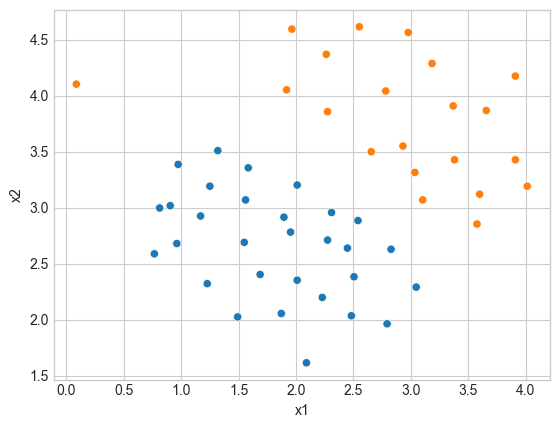

In [127]:
sns.scatterplot(data=df, x="x1", y="x2", hue="y", legend=False)

Notice that there is one outlier positive example that sits apart from the others.  The classes are still linearly separable but it's a very tight fit.  We're going to train a linear support vector machine to learn the class boundary.

#### 5. LinearSVC
Declare a Linear SVC with the hyperparamenters:

```Python
LinearSVC(C=1, loss='hinge', max_iter=10000)
```

In [128]:
from sklearn.svm import LinearSVC

svc = LinearSVC(C=1, loss='hinge', max_iter=10000)

#### 6. Try the performance (score)
For the first experiment we'll use C=1 and see how it performs.

In [129]:
X = df[['x1','x2']]
y = df['y']

svc.fit(X, y)
svc.score(X,y)

0.9803921568627451

It appears that it mis-classified the outlier.

#### 7. Increase the value of C until you get a perfect classifier

In [130]:
svc_2 = LinearSVC(C=1000, loss='hinge', max_iter=1000000)

svc_2.fit(X, y)
svc_2.score(X,y)

1.0

This time we got a perfect classification of the training data, however by increasing the value of C we've created a decision boundary that is no longer a natural fit for the data.  We can visualize this by looking at the confidence level for each class prediction, which is a function of the point's distance from the hyperplane.

#### 8. Plot Decission Function
Get the `decision_function()` output for the first model. Plot a scatterplot with X1, X2 and a range of colors based on `decision_function()`

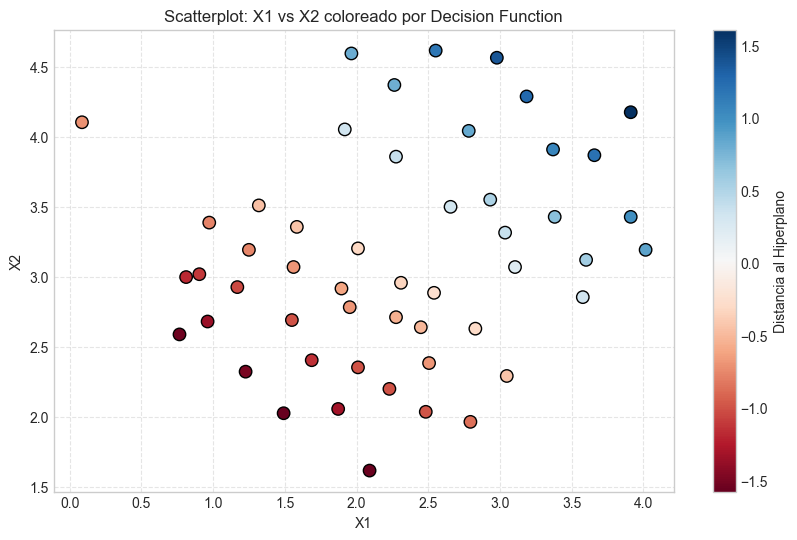

In [131]:
# 1. Obtener la confianza (distancia al hiperplano)
conf_scores = svc.decision_function(X)

# 2. Crear el scatterplot corrigiendo el acceso a los datos con .iloc
plt.figure(figsize=(10, 6))

# Usamos .iloc[:, 0] y .iloc[:, 1] para DataFrames
scatter = plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=conf_scores, cmap='RdBu', s=80, edgecolors='k')

# 3. Configurar la barra de colores y etiquetas
cbar = plt.colorbar(scatter)
cbar.set_label('Distancia al Hiperplano')

plt.title('Scatterplot: X1 vs X2 coloreado por Decision Function')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### 9. Do the same with the second model

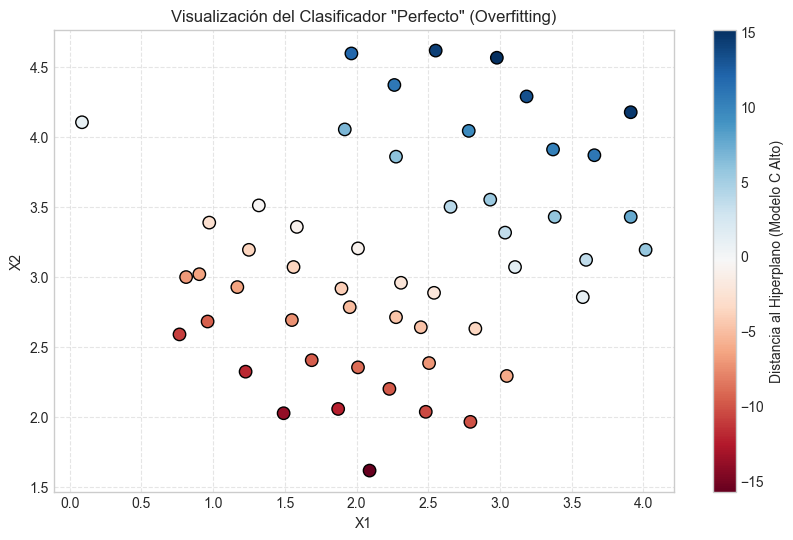

In [132]:
# 1. Obtener la confianza para el SEGUNDO modelo (el de C alta)
# Reemplaza 'svc_perfect' por el nombre de tu variable del segundo modelo
conf_scores_perfect = svc_2.decision_function(X)

# 2. Crear el scatterplot
plt.figure(figsize=(10, 6))

# Usamos .iloc para evitar el error de Pandas nuevamente
scatter = plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=conf_scores_perfect, cmap='RdBu', s=80, edgecolors='k')

# 3. Configurar la barra de colores y etiquetas
cbar = plt.colorbar(scatter)
cbar.set_label('Distancia al Hiperplano (Modelo C Alto)')

plt.title('Visualización del Clasificador "Perfecto" (Overfitting)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

https://www.svm-tutorial.com/2015/06/svm-understanding-math-part-3/

#### 1. Load the data `ejer_1_data2.mat`

In [133]:
mat_2 = scipy.io.loadmat(r"C:\Users\Eneko\2026-02-BILBAO-FT-Data-Science\3-Machine_Learning\1-Supervisado\3-RegorClass\8-SVM\ejercicios\data\ejer_1_data2.mat")

In [134]:
mat_2.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

#### 2. Create a DataFrame with the features and target

In [159]:
# 1. Crea un DataFrame usando la matriz 'X' (características) del diccionario mat_2
# Se definen 'x1' y 'x2' como los nombres de las columnas (los ejes de tus datos)
df_2 = pd.DataFrame(mat_2['X'], columns=['x1', 'x2'])

# 2. Agrega una nueva columna llamada 'y' al DataFrame
# Aquí se guardan las etiquetas de clase (los resultados esperados o "targets")
df_2['y'] = mat_2['y']

# 3. Muestra el DataFrame resultante en pantalla
# Útil para verificar que las dimensiones y los valores son correctos antes de entrenar el SVM
df_2

,x1,x2,y
0,0.107143,0.603070,1
1,0.093318,0.649854,1
2,0.097926,0.705409,1
3,0.155530,0.784357,1
4,0.210829,0.866228,1
...,...,...,...
858,0.994240,0.516667,1
859,0.964286,0.472807,1
860,0.975806,0.439474,1
861,0.989631,0.425439,1


#### 3. Plot a scatterplot with the data

<Axes: xlabel='x1', ylabel='x2'>

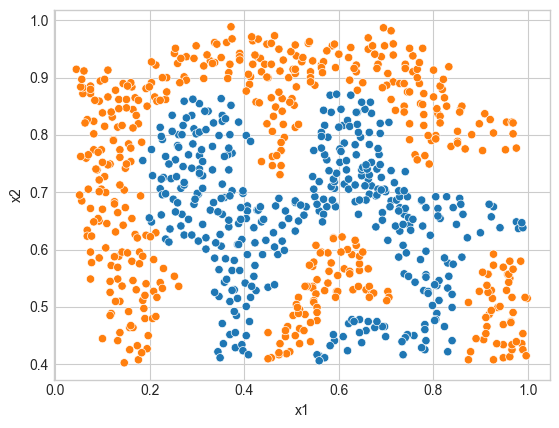

In [161]:
sns.scatterplot(data=df_2, x="x1", y="x2", hue="y", legend=False)

In [162]:
# Selecciona las columnas de entrada (características) y las guarda en la variable X
# Usamos una lista [['x1', 'x2']] para que X sea un DataFrame (matriz de 2D)
X = df_2[['x1', "x2"]]

# Selecciona la columna objetivo (etiquetas/clases) y la guarda en la variable y
# Al usar un solo corchete, 'y' es una Serie de Pandas (vector de 1D)
y = df_2['y']

c:\Users\Eneko\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


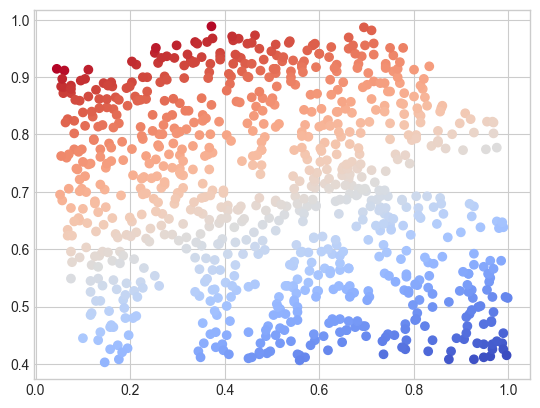

In [163]:
# 1. Configuración del clasificador lineal (Linear Support Vector Classification)
# C=1000: Un valor alto indica una penalización fuerte por errores (margen "duro" o estrecho)
# loss='hinge': Función de pérdida estándar para SVM (típica para problemas de clasificación)
# max_iter: Aumentamos el límite de iteraciones para asegurar que el algoritmo converja (encuentre solución)
svc_l = LinearSVC(C=1000, loss='hinge', max_iter=1000000)

# 2. Entrenamiento del modelo usando las características (X) y las etiquetas (y)
svc_l.fit(X, y)

# 3. Calcula la precisión (accuracy) del modelo sobre los mismos datos de entrenamiento
svc_l.score(X, y)

# 4. Obtiene la distancia de cada punto al hiperplano de decisión
# Valores cercanos a 0 están cerca del límite; valores muy positivos o negativos están lejos
conf_level = svc_l.decision_function(X)

# 5. Visualización de los resultados
# Usamos 'c=conf_level' para que el color de los puntos dependa de su confianza/distancia al margen
# 'cmap="coolwarm"' es ideal aquí: muestra la transición entre las dos clases de forma clara
plt.scatter(df_2['x1'], df_2['x2'], c=conf_level, cmap="coolwarm")

For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [164]:
# 1. Configuración del clasificador SVM con Kernel RBF (Gaussiano)
# C=100: Un valor alto que busca clasificar correctamente todos los puntos, permitiendo márgenes más estrechos.
# gamma=10: Define qué tan lejos llega la influencia de un solo punto. Un valor alto hace que el modelo se ajuste mucho a los datos (curvas más complejas).
# probability=True: Permite calcular probabilidades internas (necesario si luego quieres usar .predict_proba()).
svc_3 = SVC(C=100, gamma=10, probability=True)

#### 5. Fit the classifier and get the score

In [165]:
# Entrena el modelo SVC utilizando el kernel RBF (por defecto)
# Ajusta los parámetros internos para encontrar la frontera de decisión 
# no lineal que mejor separa las clases en función de C y gamma.
svc_3.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",10
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [166]:
# Calcula la precisión media (accuracy) del modelo sobre los mismos datos de entrenamiento.
# Devuelve un valor entre 0 y 1 que indica el porcentaje de puntos clasificados correctamente.
svc_3.score(X, y)

0.9698725376593279

#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

In [167]:
# Genera las probabilidades de pertenencia a cada clase para cada punto de X.
# y_pred_proba será una matriz donde cada fila tiene dos valores:
# [probabilidad_clase_0, probabilidad_clase_1] (ambos suman 1).
y_pred_proba = svc_3.predict_proba(X)

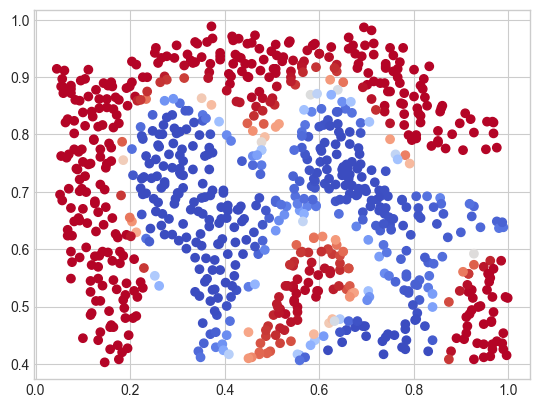

In [168]:
# Crea un gráfico de dispersión donde el color representa la probabilidad
plt.scatter(
    df_2["x1"],           # Coordenada en el eje X
    df_2["x2"],           # Coordenada en el eje Y
    c=y_pred_proba[:, 1], # Usa la probabilidad de la clase 1 (segunda columna) para el color
    cmap="coolwarm")       # Mapa de azul (baja prob.) a rojo (alta prob.) con blanco en 0.5 (incertidumbre)

In [169]:
from sklearn.model_selection import train_test_split, GridSearchCV

# Divide el dataset en dos conjuntos: uno para entrenar y otro para evaluar
# X, y: Tus datos originales
# test_size=0.2: Reserva el 20% de los datos para la prueba final (test)
# random_state=29: Fija la semilla para que la división sea siempre la misma y el experimento sea replicable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

In [170]:
# Imprime las dimensiones (filas, columnas) del conjunto de entrenamiento de X
# Útil para confirmar que el 80% de tus datos están aquí
print(X_train.shape)

# Imprime las dimensiones del conjunto de prueba de X
# Debería corresponder al 20% que definiste en el test_size
print(X_test.shape)

# Imprime la longitud del vector de etiquetas de entrenamiento
# Debe coincidir con el número de filas de X_train
print(y_train.shape)

# Imprime la longitud del vector de etiquetas de prueba
# Debe coincidir con el número de filas de X_test
print(y_test.shape)

(690, 2)
(173, 2)
(690,)
(173,)


In [171]:
# 1. Definición del "espacio de búsqueda"
# El modelo probará todas las combinaciones posibles entre estos Kernels y valores de C
parameters = {
    "kernel": ["rbf", "poly"], # Comparará el comportamiento radial vs polinómico
    "C": [10, 100, 500]        # Probará diferentes niveles de penalización por error
}

# 2. Configuración de la Búsqueda en Rejilla (Grid Search)
# svc_3: El modelo base
# cv=5: Validación cruzada de 5 pliegues (entrena y valida 5 veces para cada combinación)
# scoring="accuracy": El criterio para elegir al "ganador" será la precisión
# n_jobs=-1: Usa todos los núcleos de tu procesador para ir más rápido
# verbose=5: Muestra mensajes detallados durante el proceso para ver el progreso
gs = GridSearchCV(svc_3, parameters, cv=5, scoring="accuracy", n_jobs=-1, verbose=5)

# 3. Ejecución de la búsqueda
# Aquí el modelo entrena múltiples veces hasta encontrar la mejor combinación de parámetros
gs.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","SVC(C=100, ga...bability=True)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [10, 100, ...], 'kernel': ['rbf', 'poly']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

In [172]:
# 1. Muestra el objeto del modelo configurado con los mejores parámetros encontrados
# Incluye el kernel, C, gamma y demás hiperparámetros que dieron el mejor resultado
print(gs.best_estimator_)

# 2. Imprime únicamente el diccionario de los parámetros ganadores
# Por ejemplo: {'C': 100, 'kernel': 'rbf'}
print(gs.best_params_)

# 3. Muestra la precisión (accuracy) media obtenida mediante la validación cruzada
# Es la puntuación del "mejor modelo" durante el proceso de entrenamiento
print(gs.best_score_)

SVC(C=500, gamma=10, probability=True)
{'C': 500, 'kernel': 'rbf'}
0.972463768115942


In [173]:
# 1. Extrae el modelo ganador (el que obtuvo mejor desempeño en el GridSearch)
final_model = gs.best_estimator_

# 2. Re-entrena el modelo con el conjunto de entrenamiento completo
# Esto asegura que el modelo aproveche todos los datos disponibles en X_train
final_model.fit(X_train, y_train)

# 3. Realiza las predicciones sobre el conjunto de prueba (datos que el modelo nunca ha visto)
# Esto sirve para medir la capacidad de generalización real del SVM
y_pred = final_model.predict(X_test)

In [174]:
# Genera las probabilidades de pertenencia a cada clase para el conjunto de prueba (X_test)
# Al igual que antes, devuelve una matriz con las probabilidades para cada clase [P(0), P(1)]
# Esto te permitirá evaluar no solo si el modelo acierta, sino qué tan seguro está en datos nuevos
y_pred_proba = final_model.predict_proba(X_test)

In [175]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score

# 1. Compara las etiquetas reales (y_test) con las predicciones del modelo (y_pred)
# Devuelve la fracción de aciertos totales sobre el conjunto de prueba
print(accuracy_score(y_test, y_pred))

# 2. Genera la matriz de confusión
# Muestra cuántos puntos fueron: [Verdaderos Negativos, Falsos Positivos]
#                               [Falsos Negativos, Verdaderos Positivos]
print(confusion_matrix(y_test, y_pred))

0.976878612716763
[[74  0]
 [ 4 95]]


In [176]:
# 1. Ejecuta la Validación Cruzada (Cross-Validation) de 10 pliegues
# Divide todo el dataset en 10 partes, entrena 10 veces y evalúa cada vez en una parte distinta
results_cv = cross_val_score(final_model, X, y, cv=10, scoring="accuracy")

# 2. Imprime la precisión obtenida en cada una de las 10 iteraciones
# Útil para ver si hubo algún subconjunto de datos donde el modelo falló mucho
print(results_cv)

# 3. Calcula el promedio de las 10 puntuaciones
# Es la medida más robusta del rendimiento real que puedes esperar del modelo
print(results_cv.mean())

# 4. Calcula la desviación estándar de las puntuaciones
# Indica la variabilidad: si es muy alta, el modelo es inestable según los datos que le toquen
print(results_cv.std())

[0.96551724 0.96551724 0.96551724 1.         0.97674419 0.84883721
 0.97674419 0.8255814  0.79069767 0.86046512]
0.9175621491579792
0.07296460880852135
